In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = [
    [1000,2,30],
    [1200,2,35],
    [1400,3,42],
    [1600,3,48],
    [1800,4,55],
    [2000,4,63]
]

column_names = [
    "Area",
    "Bedrooms",
    "Price"
]

df = pd.DataFrame(data, columns=column_names)

In [3]:
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print(df)

display(df)

   Area  Bedrooms  Price
0  1000         2     30
1  1200         2     35
2  1400         3     42
3  1600         3     48
4  1800         4     55
5  2000         4     63


,Area,Bedrooms,Price
0,1000,2,30
1,1200,2,35
2,1400,3,42
3,1600,3,48
4,1800,4,55
5,2000,4,63


In [4]:
X = df[["Area","Bedrooms"]]

y = df["Price"]

display(X)

display(y)

,Area,Bedrooms
0,1000,2
1,1200,2
2,1400,3
3,1600,3
4,1800,4
5,2000,4


,Price
0,30
1,35
2,42
3,48
4,55
5,63


In [5]:
model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [6]:
area = np.linspace(df["Area"].min(), df["Area"].max(),20)

bedrooms = np.linspace(df["Bedrooms"].min(),df["Bedrooms"].max(),20)

area, bedrooms = np.meshgrid(area, bedrooms)

In [7]:
price = model.predict(
    np.c_[area.ravel(), bedrooms.ravel()]
)

price = price.reshape(area.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


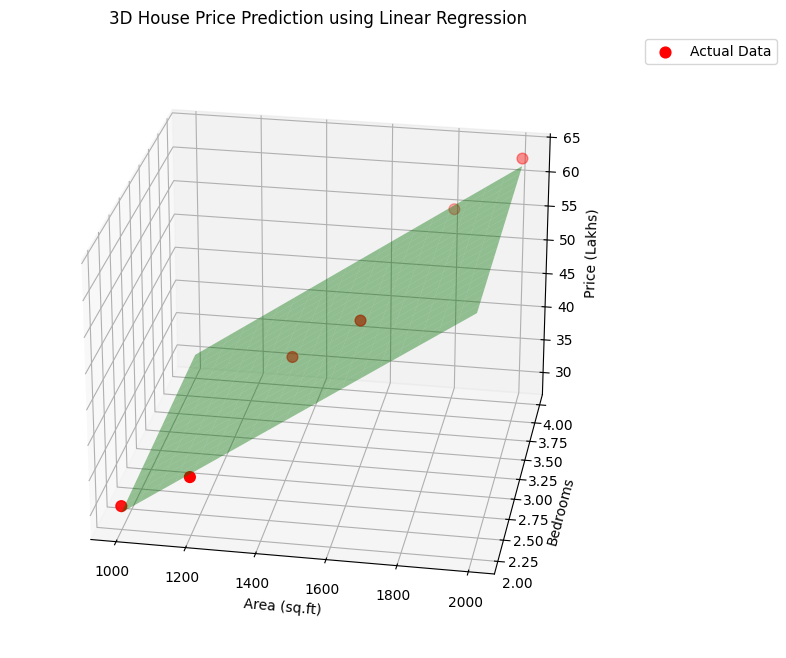

In [8]:

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection="3d")


ax.scatter(
    df["Area"],
    df["Bedrooms"],
    df["Price"],
    color="red",
    s=60,
    label="Actual Data"
)


ax.plot_surface(
    area,
    bedrooms,
    price,
    color="green",
    alpha=0.4
)


ax.set_xlabel("Area (sq.ft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price (Lakhs)")

ax.view_init(elev=25, azim=-80)


plt.title("3D House Price Prediction using Linear Regression")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

In [9]:
new_house = [[1700,3]]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0],"Lakhs")

Predicted House Price: 51.83333333333333 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
new_house = pd.DataFrame({
    "Area": [1700],
    "Bedrooms": [3]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", round(predicted_price[0],2), "Lakhs")

Predicted House Price: 51.83 Lakhs
